<a href="https://colab.research.google.com/github/dithya-332/ml-lab/blob/main/EXPERIMENT%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
#load dataset
url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
data=pd.read_csv(url)



In [6]:
#select required columns
data=data[['mpg','displacement']]
data.dropna(inplace=True)

In [10]:
print(data.head())


    mpg  displacement
0  18.0         307.0
1  15.0         350.0
2  18.0         318.0
3  16.0         304.0
4  17.0         302.0


In [13]:
#features and target
x=data[['displacement']]
y=data['mpg']
#train-test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [15]:
# linera regression
linear_model=LinearRegression()
linear_model.fit(x_train,y_train)
y_pred=linear_model.predict(x_test)
print("linear regression")
print("MSE=",mean_squared_error(y_test,y_pred))
print("R2=",r2_score(y_test,y_pred))

linear regression
MSE= 18.102543998358946
R2= 0.6633114869465596


In [16]:
degrees=[2,3,4]
for degree in degrees:
    poly=PolynomialFeatures(degree)
    x_train_poly=poly.fit_transform(x_train)
    x_test_poly=poly.transform(x_test)
    model=LinearRegression()
    model.fit(x_train_poly,y_train)
    y_pred=model.predict(x_test_poly)
    print("\nDegree=",degree)
    print("MSE=",mean_squared_error(y_test,y_pred))
    print("R2=",r2_score(y_test,y_pred))


Degree= 2
MSE= 15.10735356108076
R2= 0.7190189176110284

Degree= 3
MSE= 14.943631793037289
R2= 0.722063972418907

Degree= 4
MSE= 14.961486893912738
R2= 0.7217318860908903


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


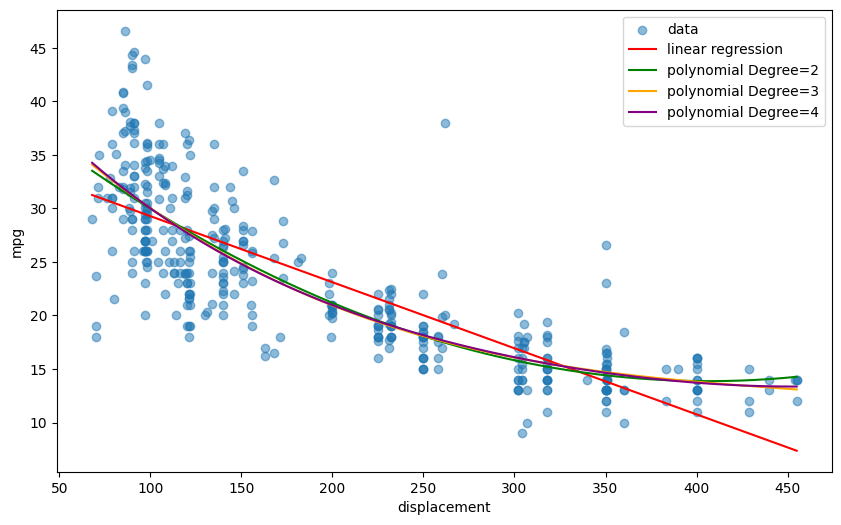

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

x_range=np.linspace(x.min(),x.max(),300).reshape(-1,1)
plt.figure(figsize=(10,6))
plt.scatter(x,y,alpha=0.5,label='data')
plt.plot(x_range,linear_model.predict(x_range)
,color='red',
label='linear regression')
colors=['green','orange','purple']
for degree,color in zip([2,3,4],colors):
  poly=PolynomialFeatures(degree)
  x_poly=poly.fit_transform(x)
  model=LinearRegression()
  model.fit(x_poly,y)
  plt.plot(x_range,
           model.predict(poly.transform(x_range)),
           color=color,
           label=f'polynomial Degree={degree}')
plt.xlabel('displacement')
plt.ylabel('mpg')
plt.legend()
plt.show()